<a href="https://colab.research.google.com/github/echowdaryy-create/2D-game-transformation-engine-/blob/main/FLUX2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown

# Set display preferences for cleaner math output
sp.init_printing(use_latex='mathjax')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# Cell 2: Configuration & Dynamic Inputs

# Initial Triangle Vertices (Row vectors: [x, y])
vertices_2d = np.array([
    [0.0, 0.0],  # Vertex A
    [2.0, 0.0],  # Vertex B
    [1.0, 2.0]   # Vertex C
])

# Transformation Parameters
scale_factor = 1.5           # Uniform scaling factor (s)
rotation_angle_deg = 45.0    # Rotation angle in degrees (θ)
translation_x = 3.0          # Horizontal shift (tx)
translation_y = 2.0          # Vertical shift (ty)

print("Configuration Loaded Successfully.")

Configuration Loaded Successfully.


In [ ]:
# Cell 3: Analytical Derivation with SymPy

# Define symbolic variables
theta, s, tx, ty = sp.symbols('theta s t_x t_y', real=True)

# 1. Scaling Matrix S(s)
S_sym = sp.Matrix([
    [s, 0, 0],
    [0, s, 0],
    [0, 0, 1]
])

# 2. Rotation Matrix R(theta)
R_sym = sp.Matrix([
    [sp.cos(theta), -sp.sin(theta), 0],
    [sp.sin(theta),  sp.cos(theta), 0],
    [0,             0,             1]
])

# 3. Translation Matrix T(tx, ty)
T_sym = sp.Matrix([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

# Step-by-Step Composition
RS_sym = R_sym * S_sym
M_total_sym = T_sym * RS_sym

display(Markdown("### Symbolic Matrix Models"))
display(Markdown("**Scaling Matrix $S(s)$:**"))
display(S_sym)

display(Markdown("**Rotation Matrix $R(\\theta)$:**"))
display(R_sym)

display(Markdown("**Translation Matrix $T(t_x, t_y)$:**"))
display(T_sym)

display(Markdown("**Composite Transformation Matrix $M_{\\text{total}} = T \\cdot R \\cdot S$:**"))
display(M_total_sym)

### Symbolic Matrix Models

**Scaling Matrix $S(s)$:**

⎡s  0  0⎤
⎢       ⎥
⎢0  s  0⎥
⎢       ⎥
⎣0  0  1⎦

**Rotation Matrix $R(\theta)$:**

⎡cos(θ)  -sin(θ)  0⎤
⎢                  ⎥
⎢sin(θ)  cos(θ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦

**Translation Matrix $T(t_x, t_y)$:**

⎡1  0  tₓ ⎤
⎢         ⎥
⎢0  1  t_y⎥
⎢         ⎥
⎣0  0   1 ⎦

**Composite Transformation Matrix $M_{\text{total}} = T \cdot R \cdot S$:**

⎡s⋅cos(θ)  -s⋅sin(θ)  tₓ ⎤
⎢                        ⎥
⎢s⋅sin(θ)  s⋅cos(θ)   t_y⎥
⎢                        ⎥
⎣   0          0       1 ⎦

<IPython.core.display.Math object>

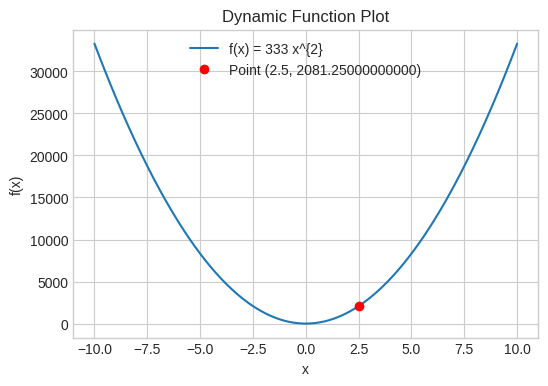

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Math, display

# Initialize sympy printing
sp.init_printing(use_latex='mathjax')

# @title Interactive Math Calculator { run: "auto" }
# @markdown Enter values to update the calculation and plot automatically:

coefficient = 333  # @param {type:"number"}
power = 2  # @param {type:"integer"}
x_val = 2.5  # @param {type:"number"}

# 1. Define symbolic variable and equation
x = sp.Symbol('x')
expr = coefficient * x**power
result = expr.subs(x, x_val)

# 2. Display formatted LaTeX output
display(
    Math(
        f'f(x) = {sp.latex(expr)} \\quad \\implies \\quad f({x_val}) ='
        f' {result}'
    )
)

# 3. Generate and display the plot
x_vals = np.linspace(-10, 10, 400)
y_vals = coefficient * x_vals**power

plt.figure(figsize=(6, 4))
plt.plot(x_vals, y_vals, label=f'f(x) = {sp.latex(expr)}')
plt.plot(x_val, result, 'ro', label=f'Point ({x_val}, {result})')
plt.title('Dynamic Function Plot')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Math, Markdown, clear_output, display

sp.init_printing(use_latex='mathjax')
x = sp.Symbol('x')

# Create input fields for output area
a_input = widgets.FloatText(value=3.0, description='Value a:')
b_input = widgets.FloatText(value=2.0, description='Value b:')
x_input = widgets.FloatText(value=2.5, description='Value x:')
button = widgets.Button(
    description='Calculate Output', button_style='primary'
)
output_area = widgets.Output()


def calculate_on_click(b):
  with output_area:
    clear_output()
    a_val = a_input.value
    b_val = b_input.value
    x_val = x_input.value

    expr = a_val * x**b_val
    result = expr.subs(x, x_val)

    display(Markdown('### Calculation Output'))
    display(
        Math(
            f'f(x) = {sp.latex(expr)} \\quad \\implies \\quad f({x_val}) ='
            f' {float(result):.4f}'
        )
    )

    # Plot
    x_vals = np.linspace(-10, 10, 400)
    f_num = sp.lambdify(x, expr, 'numpy')
    y_vals = np.real(f_num(x_vals))

    plt.figure(figsize=(7, 4))
    plt.plot(x_vals, y_vals, label=f'$f(x) = {sp.latex(expr)}$', color='navy')
    plt.plot(
        x_val,
        float(result),
        'ro',
        markersize=8,
        label=f'Point ({x_val}, {float(result):.2f})',
    )
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()


button.on_click(calculate_on_click)

# Display interactive UI components in the output
display(
    widgets.VBox(
        [a_input, b_input, x_input, button, output_area]
    )
)

In [ ]:

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Math, Markdown, clear_output, display

# Initialize sympy printing
sp.init_printing(use_latex='mathjax')
x, y = sp.symbols('x y')

# Create input widgets for output area
a_input = widgets.FloatText(value=3.0, description='Value a:')
b_input = widgets.FloatText(value=2.0, description='Value b:')
x_input = widgets.FloatText(value=2.5, description='Value x:')
y_input = widgets.FloatText(value=1.5, description='Value y:')
button = widgets.Button(
    description='Calculate Output', button_style='primary'
)
output_area = widgets.Output()


def calculate_on_click(btn):
  with output_area:
    clear_output()
    a_val = a_input.value
    b_val = b_input.value
    x_val = x_input.value
    y_val = y_input.value

    # 1. Define 2D and 3D Symbolic Expressions
    expr_2d = a_val * x**b_val
    expr_3d = a_val * x**b_val + y**2

    result_2d = expr_2d.subs(x, x_val)
    result_3d = expr_3d.subs({x: x_val, y: y_val})

    # 2. Display LaTeX Formatted Equations and Calculations
    display(Markdown('### Calculation Results'))
    display(
        Math(
            f'f(x) = {sp.latex(expr_2d)} \\quad \\implies \\quad f({x_val}) ='
            f' {float(result_2d):.4f}'
        )
    )
    display(
        Math(
            f'f(x, y) = {sp.latex(expr_3d)} \\quad \\implies \\quad f({x_val},'
            f' {y_val}) = {float(result_3d):.4f}'
        )
    )

    # 3. Create Figure with 2D and 3D Subplots
    fig = plt.figure(figsize=(14, 5))

    # --- 2D Plot Subplot ---
    ax1 = fig.add_subplot(1, 2, 1)
    x_vals = np.linspace(-10, 10, 400)
    f_num_2d = sp.lambdify(x, expr_2d, 'numpy')
    y_vals = np.real(f_num_2d(x_vals))

    ax1.plot(
        x_vals, y_vals, label=f'$f(x) = {sp.latex(expr_2d)}$', color='navy'
    )
    ax1.plot(
        x_val,
        float(result_2d),
        'ro',
        markersize=8,
        label=f'Point ({x_val}, {float(result_2d):.2f})',
    )
    ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax1.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax1.set_title('2D Function Plot')
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- 3D Surface Subplot ---
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    X_grid, Y_grid = np.meshgrid(
        np.linspace(-5, 5, 50), np.linspace(-5, 5, 50)
    )

    f_num_3d = sp.lambdify((x, y), expr_3d, 'numpy')
    Z_grid = np.real(f_num_3d(X_grid, Y_grid))

    surf = ax2.plot_surface(
        X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.85, edgecolor='none'
    )
    ax2.scatter(
        [x_val],
        [y_val],
        [float(result_3d)],
        color='red',
        s=80,
        label=f'Point ({x_val}, {y_val}, {float(result_3d):.2f})',
    )

    ax2.set_title('3D Surface Plot ($z = f(x, y)$)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=6)
    ax2.legend()

    plt.tight_layout()
    plt.show()


button.on_click(calculate_on_click)

# Display UI Layout
display(
    widgets.VBox([a_input, b_input, x_input, y_input, button, output_area])
)